In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("stock_6_train.csv")
test_df = pd.read_csv("stock_6_test.csv")

In [3]:
df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,target
0,-0.570944,0.813764,1.068472,0.232878,0.234401,0.270343,0.471025,-0.760052,146.787077
1,-0.205162,-2.003522,1.604254,-0.457699,0.107880,1.309551,0.071674,-0.375889,196.708960
2,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,0.173653,-0.798076,125.201647
3,-0.189244,0.328662,0.361922,1.320662,-0.342786,-1.476858,1.357183,-0.146051,122.023737
4,-0.878152,-0.334123,0.915903,-1.326393,0.030631,-0.484169,-1.094665,-1.434372,195.946833
...,...,...,...,...,...,...,...,...,...
114,-0.707265,0.968998,-0.361833,-0.489750,0.908601,0.031086,-0.171234,-0.451510,177.044909
115,-0.594150,-1.446058,0.072130,-0.529493,0.232676,0.021852,-1.258604,0.264255,199.701818
116,0.777767,0.807008,-1.619872,-2.247269,1.001745,1.187725,-0.535677,0.079271,235.489057
117,-1.993060,-1.296472,-1.482185,-2.333616,-0.678264,0.749434,-2.684137,-2.473157,356.521140


Only 119 rows on this round.

In [4]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,target
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,-0.155919,0.018287,0.103290,-0.020963,-0.010924,-0.091031,0.004951,-0.173031,172.239048
std,0.957837,0.976865,1.056809,0.978773,1.000320,1.092289,1.106233,1.190063,54.923302
min,-2.964529,-2.063238,-2.394260,-2.930594,-2.409922,-3.648413,-2.684137,-3.069494,80.000000
25%,-0.848291,-0.693576,-0.501371,-0.616294,-0.546736,-0.866644,-0.722181,-0.942702,140.497456
50%,-0.152523,0.063002,0.090585,-0.049926,0.030631,-0.048718,0.053079,-0.146051,164.750020
75%,0.471337,0.650478,0.831898,0.585842,0.687588,0.655075,0.678239,0.697464,190.676204
max,2.905067,2.093168,2.517474,2.913862,2.382602,2.242920,2.414772,2.536973,400.000000


features normally distributed

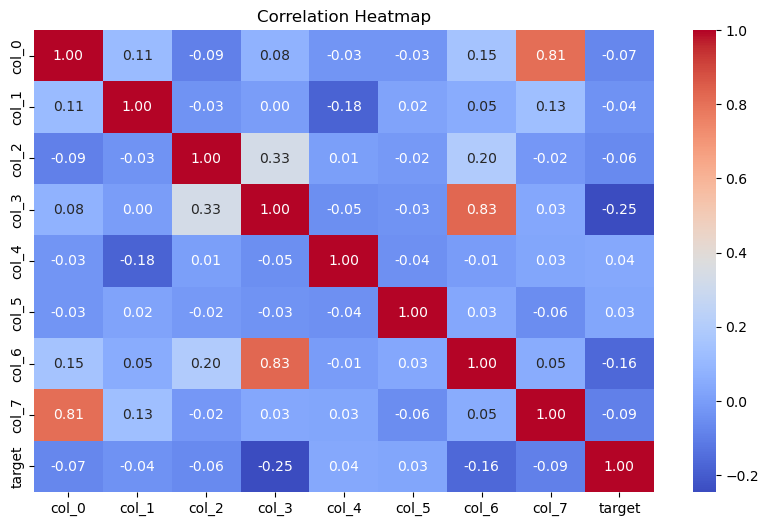

In [5]:
corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Features are all correlated in some way, allowing opportunities for feature engineering.

**col_0** and **col_7** are highly correlated

**col_3** and **col_6** are highly correlated

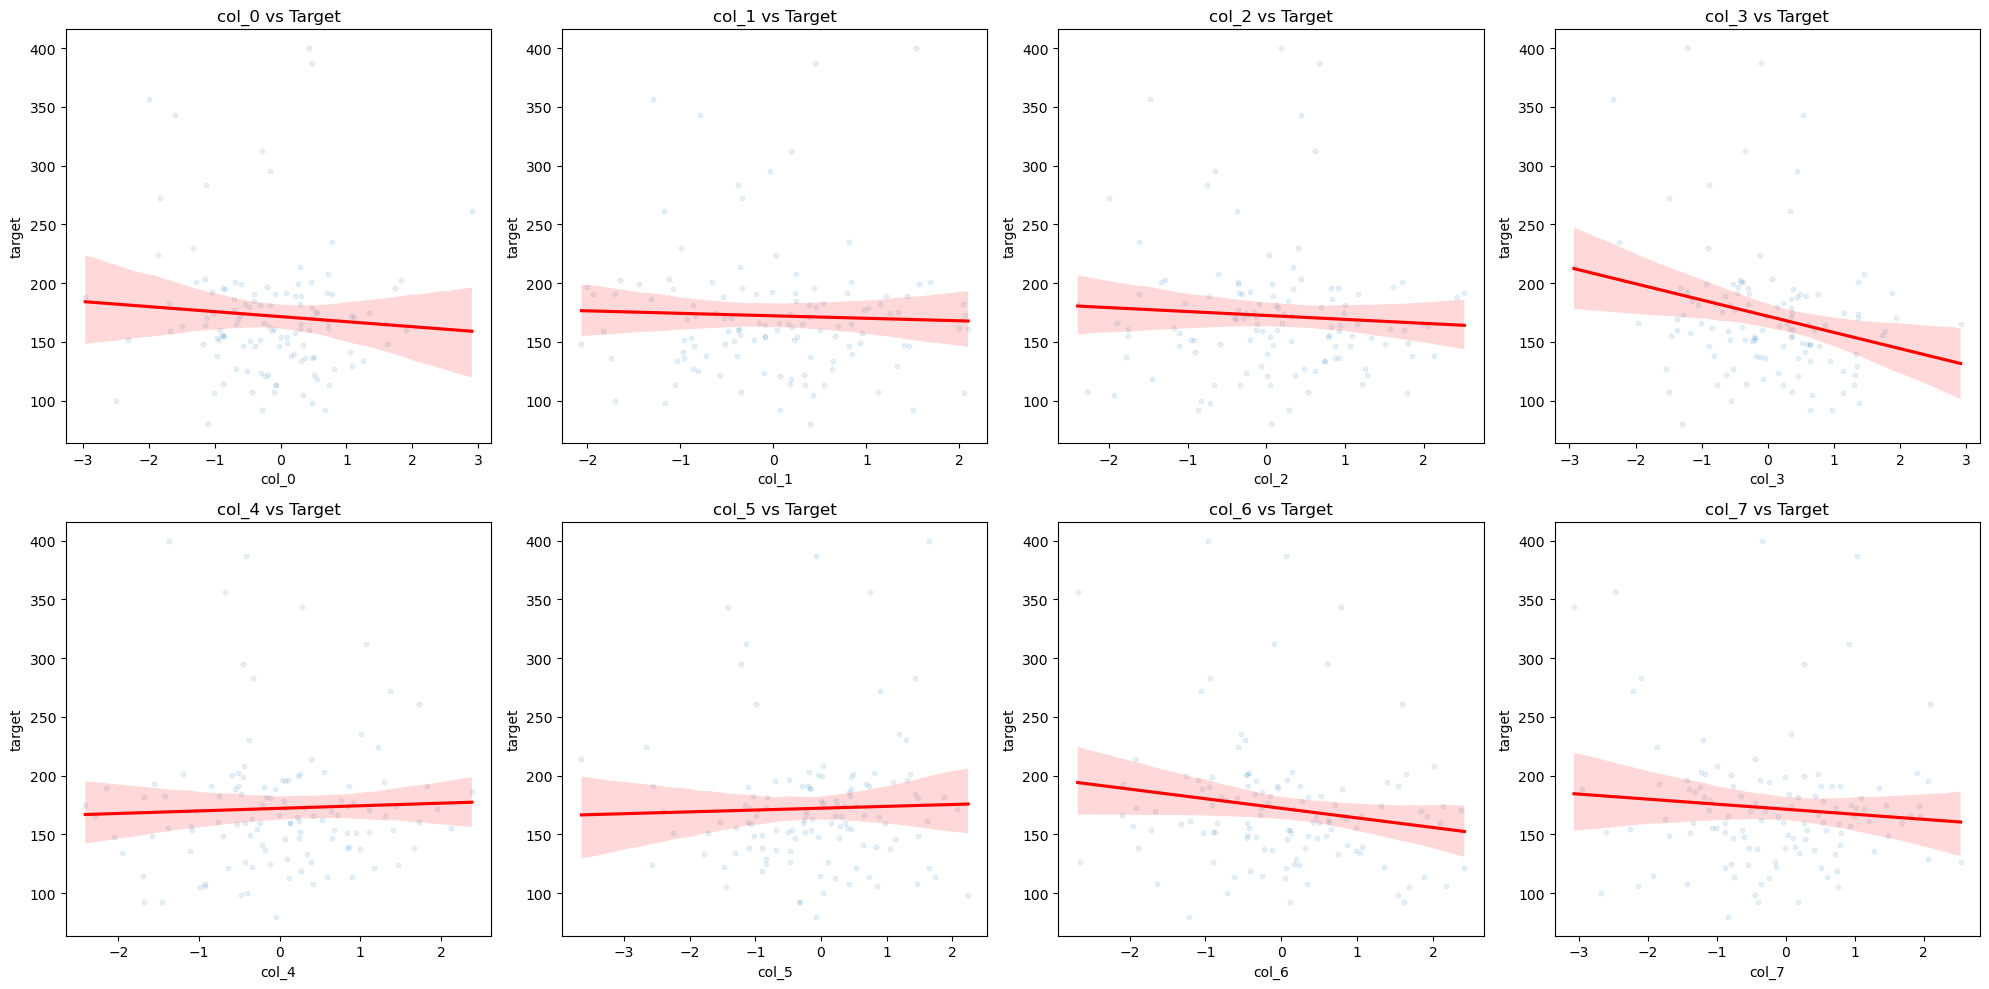

In [13]:
features = [col for col in df.columns if col.startswith('col_')]

# Create a grid: 2 rows by 4 columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    if i >= len(axes):
        break
        
    sns.regplot(x=df[col], y=df['target'], ax=axes[i], 
                scatter_kws={'alpha':0.1, 's':10}, 
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

Data has a large variance for each column and there are not many data points (only 199)

In [7]:
df['col_0_cut'] = pd.qcut(df['col_0'], 8)
df.groupby(["col_0_cut"], as_index=False, observed=True)['target'].mean()

,col_0_cut,target
0,"(-2.9659999999999997, -1.131]",206.052579
1,"(-1.131, -0.848]",159.163028
2,"(-0.848, -0.423]",165.780496
3,"(-0.423, -0.153]",175.270153
4,"(-0.153, 0.225]",150.574365
5,"(0.225, 0.471]",181.557789
6,"(0.471, 0.752]",164.061633
7,"(0.752, 2.905]",174.008027


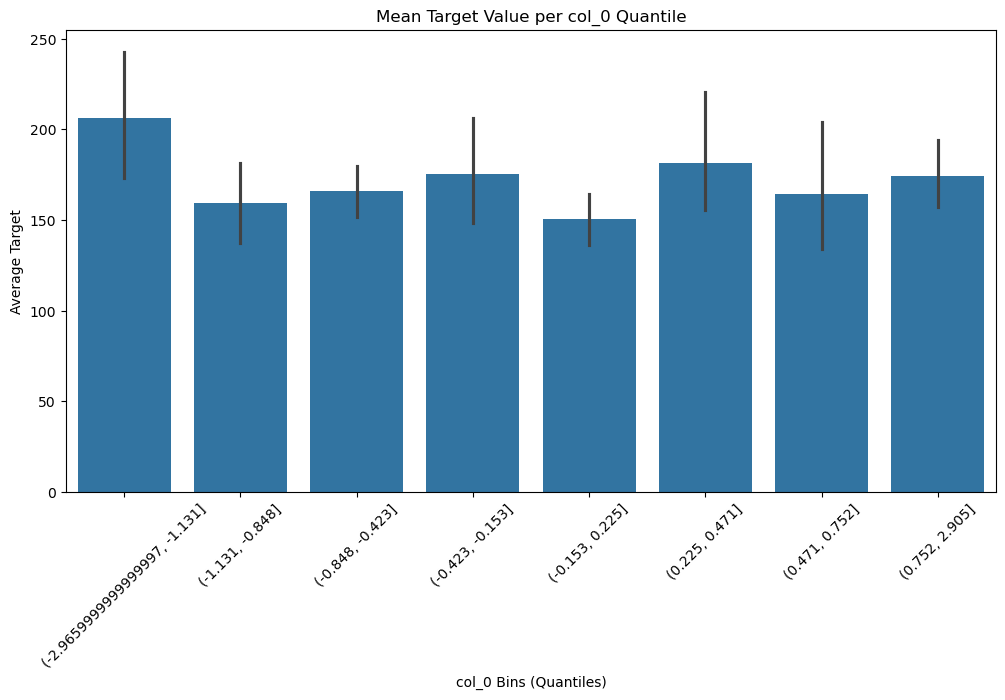

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_0_cut', y='target')
plt.title('Mean Target Value per col_0 Quantile')
plt.xlabel('col_0 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [14]:
stats_df = df.groupby("col_0_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_0_cut,,,,,,,
"(-2.9659999999999997, -1.131]",206.052579,188.655254,71.094643,15,100.075803,356.521140,0.345032
"(-1.131, -0.848]",159.163028,155.130859,46.227000,15,80.000000,283.515489,0.290438
"(-0.848, -0.423]",165.780496,172.732670,28.558078,15,107.654181,200.808371,0.172264
"(-0.423, -0.153]",175.270153,166.286563,60.251505,15,92.379676,312.225030,0.343764
"(-0.153, 0.225]",150.574365,151.582566,27.557398,14,107.779364,191.529218,0.183015
"(0.225, 0.471]",181.557789,165.611752,66.921027,15,104.963261,400.000000,0.368594
"(0.471, 0.752]",164.061633,161.895062,70.861176,15,92.163825,387.079815,0.431918
"(0.752, 2.905]",174.008027,171.393473,38.511371,15,126.949489,261.402359,0.221320


bins with high noise ratios are less trustworthy.